# 🛍️ RetailLens — Customer Segmentation & Churn Intelligence
### RFM Analysis + K-Means Clustering on UCI Online Retail II Dataset

---

| | |
|---|---|
| **Author** | Krupal Gohil |
| **Dataset** | [UCI Online Retail II](https://archive.ics.uci.edu/dataset/502/online+retail+ii) |
| **Domain** | E-Commerce / Customer Analytics / CRM |
| **Techniques** | EDA · RFM Feature Engineering · K-Means Clustering · Churn Risk Scoring |
| **Tools** | Python · Pandas · Scikit-Learn · Seaborn · Matplotlib |
| **Goal** | Segment ~4,300 customers into 7 actionable groups to drive targeted marketing strategy |

---

## Table of Contents

| Step | Section |
|------|---------|
| 1 | Business Problem |
| 2 | Dataset Overview |
| 3 | Setup & Imports |
| 4 | Load Data |
| 5 | Data Inspection |
| 6 | Exploratory Data Analysis (EDA) |
| 7 | Data Cleaning |
| 8 | RFM Feature Engineering |
| 9 | Log Transformation |
| 10 | Outlier Handling |
| 11 | Scaling |
| 12 | Finding the Right Number of Clusters |
| 13 | Final Model & Visualisation |
| 14 | Cluster Profiling & Labeling |
| 15 | Premium Customer Segments |
| 16 | Churn Risk Scoring |
| 17 | Final Segment Dashboard |
| 18 | Business Recommendations |
| 19 | Conclusion |


---
## Step 1 — Business Problem

### The Situation

A UK-based online gift retailer has been running for over a year. They sell across 40 countries and have processed more than 500,000 transactions.

But here is the problem — **they treat every customer the same.**

They send the same email to everyone, run the same promotions for everyone, and have no idea who their best customers are. This means:

- Their best customers get no special treatment and may leave
- Money is wasted on customers who never come back
- No one knows which customers are about to stop buying

### The Solution

We use **customer segmentation** — grouping customers by their purchasing behaviour — so the business can treat different customers differently.

The framework we use is called **RFM**:

| Letter | Stands for | What it measures |
|--------|-----------|-----------------|
| **R** | Recency | How recently did the customer buy? |
| **F** | Frequency | How often do they buy? |
| **M** | Monetary | How much do they spend in total? |

Using these three numbers for each customer, we apply **K-Means Clustering** to automatically group customers into segments.

### Business Questions We Want to Answer

| # | Question |
|---|---------|
| Q1 | Which countries and products generate the most revenue? |
| Q2 | What does customer spending behaviour look like — are most customers low spenders? |
| Q3 | How recently and how often do customers typically purchase? |
| Q4 | How many natural customer groups exist in the data? |
| Q5 | What are the characteristics of each customer group? |
| Q6 | Which customers are at risk of leaving (churning)? |


---
## Step 2 — Dataset Overview

**Dataset:** UCI Online Retail II — real transaction data from a UK online gift retailer

**Source:** [UCI Machine Learning Repository](https://archive.ics.uci.edu/dataset/502/online+retail+ii)

**Size:** ~525,000 transactions across 2 years (Dec 2009 – Dec 2010)

### Column Descriptions

| Column | Description |
|--------|-------------|
| `Invoice` | Unique 6-digit invoice number. Starts with `C` = cancellation, `A` = bad debt |
| `StockCode` | Product code |
| `Description` | Product name |
| `Quantity` | Units sold. Negative = return/refund |
| `InvoiceDate` | Date and time of the transaction |
| `Price` | Price per unit in GBP (£) |
| `Customer ID` | Unique customer identifier — some transactions have no ID (guest checkouts) |
| `Country` | Country where the customer is based |

### What We Will Build From This Data

This is transaction-level data — one row per item per invoice.

We need to **aggregate it to customer level** to create RFM features. By the end of the cleaning and engineering steps, each row will represent one customer with three numbers: Recency, Frequency, and Monetary value.


---
## Step 3 — Setup & Imports


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 100



---
## Step 4 — Load Data

We load Sheet 0 from the Excel file, which covers December 2009 to December 2010.


In [2]:
df = pd.read_excel('online_retail_II.xlsx', sheet_name=0)

print(f"Rows    : {df.shape[0]:,}")
print(f"Columns : {df.shape[1]}")

df.head()


Rows    : 525,461
Columns : 8


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


---
## Step 5 — Data Inspection

Before any analysis or cleaning, we look at the raw data to understand its structure and spot any obvious problems.

We check:
- Data types for each column
- How many values are missing
- Basic statistics (min, max, average)


In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 525461 entries, 0 to 525460
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      525461 non-null  object        
 1   StockCode    525461 non-null  object        
 2   Description  522533 non-null  object        
 3   Quantity     525461 non-null  int64         
 4   InvoiceDate  525461 non-null  datetime64[ns]
 5   Price        525461 non-null  float64       
 6   Customer ID  417534 non-null  float64       
 7   Country      525461 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 32.1+ MB


In [4]:
df.describe()


,Quantity,InvoiceDate,Price,Customer ID
count,525461.000000,525461,525461.000000,417534.000000
mean,10.337667,2010-06-28 11:37:36.845017856,4.688834,15360.645478
min,-9600.000000,2009-12-01 07:45:00,-53594.360000,12346.000000
25%,1.000000,2010-03-21 12:20:00,1.250000,13983.000000
50%,3.000000,2010-07-06 09:51:00,2.100000,15311.000000
75%,10.000000,2010-10-15 12:45:00,4.210000,16799.000000
max,19152.000000,2010-12-09 20:01:00,25111.090000,18287.000000
std,107.424110,NaN,146.126914,1680.811316


> **Observation:** The dataset has ~525K rows. Key red flags: `Customer ID` has ~108K missing values (guest checkouts), `Quantity` has negative values (returns), and `Price` has extreme outliers and a few negatives (bad-debt entries). All of these need to be addressed in the cleaning step.


### Missing Values


In [5]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

missing_report = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_report[missing_report['Missing Count'] > 0]


,Missing Count,Missing %
Description,2928,0.56
Customer ID,107927,20.54


> **Observation:** `Customer ID` is missing for about 20% of rows — these are guest checkouts with no customer identity. We cannot track these customers over time, so they must be removed before building RFM features. `Description` has a tiny number of nulls which is fine since we don't use it in the model.


### Quick Look at Negative Values


In [6]:
print(f"Rows with negative Quantity : {(df['Quantity'] < 0).sum():,}")
print(f"Rows with negative Price    : {(df['Price'] < 0).sum():,}")
print(f"Rows with zero Price        : {(df['Price'] == 0).sum():,}")


Rows with negative Quantity : 12,326
Rows with negative Price    : 3
Rows with zero Price        : 3,687


> **Observation:** Negative quantities are product returns and cancellations. The 3 negative price rows are bad-debt adjustment entries. Zero-price rows are free samples or admin entries. All of these need to be removed — if kept, they would reduce a customer's MonetaryValue and distort the RFM scores.


---
## Step 6 — Exploratory Data Analysis (EDA)

EDA means exploring the data to understand patterns before we do any modelling.

We will explore:
- Which countries and products generate the most revenue
- How transaction volume changes over time
- What the distribution of transaction amounts looks like
- Who the top customers are


### 6.1 — Revenue by Country

Create a quick revenue column (Price × Quantity) to understand geographic distribution.


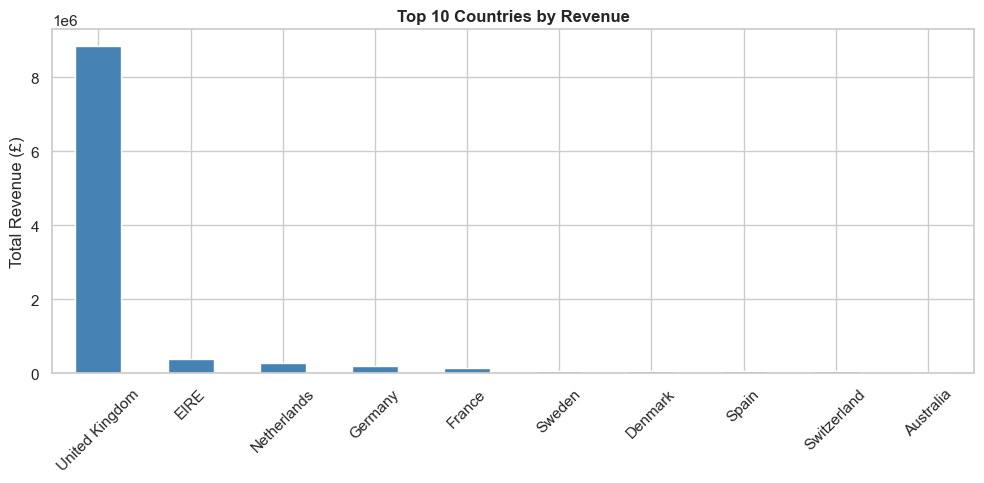

UK share of total revenue: 87.8%


In [7]:
eda_df = df.copy()
eda_df['Revenue'] = eda_df['Quantity'] * eda_df['Price']

# Keep only positive revenue (real purchases)
eda_pos = eda_df[eda_df['Revenue'] > 0]

top_countries = (
    eda_pos.groupby('Country')['Revenue']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

fig, ax = plt.subplots(figsize=(10, 5))
top_countries.plot(kind='bar', ax=ax, color='steelblue')
ax.set_title('Top 10 Countries by Revenue', fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('Total Revenue (£)')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig("Visuals\Top 10 Countries by Revenue", dpi=300, bbox_inches="tight")
plt.show()

print(f"UK share of total revenue: {top_countries['United Kingdom']/top_countries.sum()*100:.1f}%")


- **Finding (Q1 answered):** The United Kingdom dominates revenue by a large margin. The retailer is primarily a UK business. A small number of other countries (Netherlands, EIRE, Germany, France) make up most of the remaining revenue. This tells us the business should focus retention efforts on UK customers first.


### 6.2 — Monthly Revenue Trend


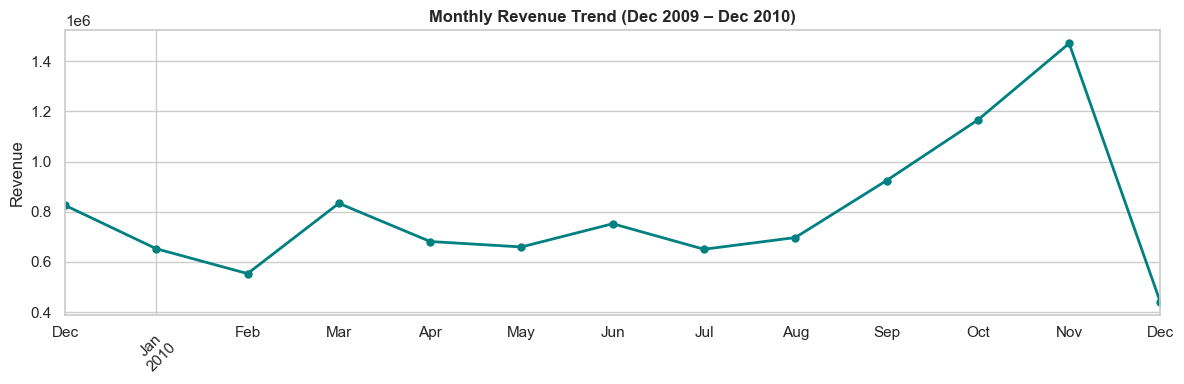

In [8]:
eda_pos = eda_pos.copy()
eda_pos['Month'] = pd.to_datetime(eda_pos['InvoiceDate']).dt.to_period('M')

monthly_revenue = eda_pos.groupby('Month')['Revenue'].sum()

fig, ax = plt.subplots(figsize=(12, 4))
monthly_revenue.plot(ax=ax, color='teal', marker='o', linewidth=2, markersize=5)
ax.set_title('Monthly Revenue Trend (Dec 2009 – Dec 2010)', fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('Revenue')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig("Visuals\Monthly Revenue Trend (Dec 2009 – Dec 2010)", dpi=300, bbox_inches="tight")
plt.show()


- **Finding:** Revenue shows a clear seasonal pattern with a large spike towards the end of the year — driven by Christmas gift purchasing. This is important context for segmentation: customers who bought only in November/December may appear as high-value but are actually seasonal buyers.


### 6.3 — Top 10 Products by Revenue


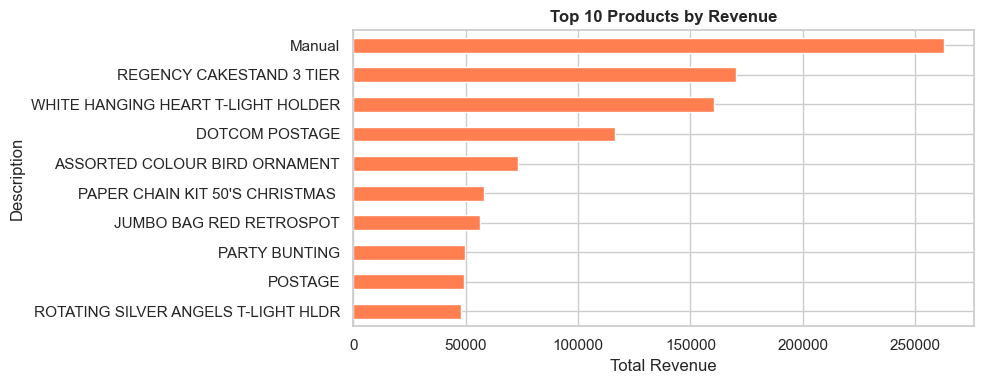

In [9]:
top_products = (
    eda_pos.groupby('Description')['Revenue']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

fig, ax = plt.subplots(figsize=(10, 4))
top_products.plot(kind='barh', ax=ax, color='coral', edgecolor='white')
ax.set_title('Top 10 Products by Revenue', fontweight='bold')
ax.set_xlabel('Total Revenue')
ax.invert_yaxis()
plt.savefig("Visuals\Top 10 Products by Revenue", dpi=300, bbox_inches="tight")
plt.tight_layout()

plt.show()


- **Finding:** The top products are mostly decorative homeware and gift items — consistent with the retailer's description as an online gift shop. There is no single product that dominates revenue, which means the business is not overly dependent on one item.


### 6.4 — Transaction Amount Distribution

How much do people typically spend per transaction?


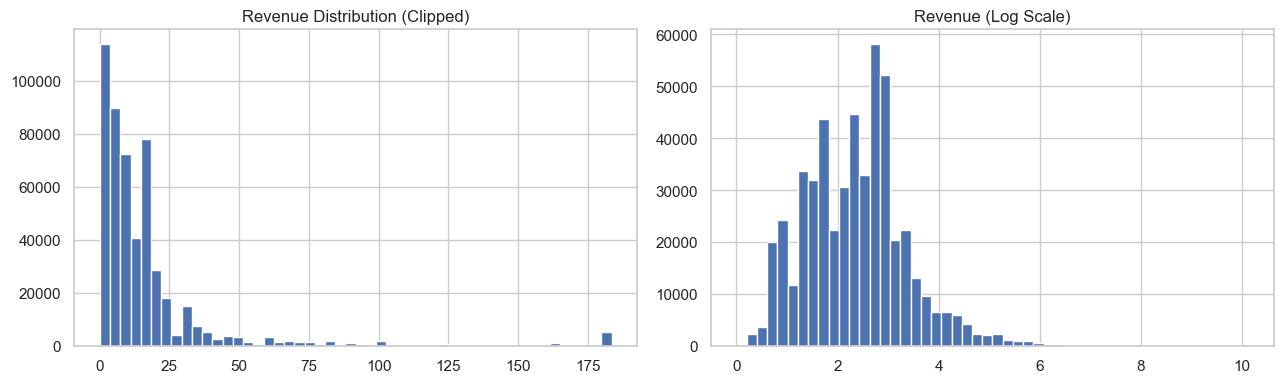

Median: 10.14
Mean: 20.15
90%: 33.90


In [10]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4))

# Clip extreme values
rev = eda_pos['Revenue']
clip_val = rev.quantile(0.99)

# Normal distribution
rev.clip(upper=clip_val).hist(bins=50, ax=ax[0])
ax[0].set_title('Revenue Distribution (Clipped)')

# Log distribution
np.log1p(rev).hist(bins=50, ax=ax[1])
ax[1].set_title('Revenue (Log Scale)')

plt.tight_layout()
plt.savefig("Visuals\Transaction amount distribution", dpi=300, bbox_inches="tight")

plt.show()

# Key stats 
print(f"Median: {rev.median():.2f}")
print(f"Mean: {rev.mean():.2f}")
print(f"90%: {rev.quantile(0.9):.2f}")

- **Finding (Q2 answered):** The distribution is heavily right-skewed — most transactions are small (median around 10–15), but a small number of very large orders pull the average up significantly. This means most customers are low spenders, but a small group of high-value customers drives a disproportionate share of revenue. This is the classic "80/20" pattern that makes segmentation so valuable.


### 6.5 — Number of Orders per Customer

How often do customers typically buy?


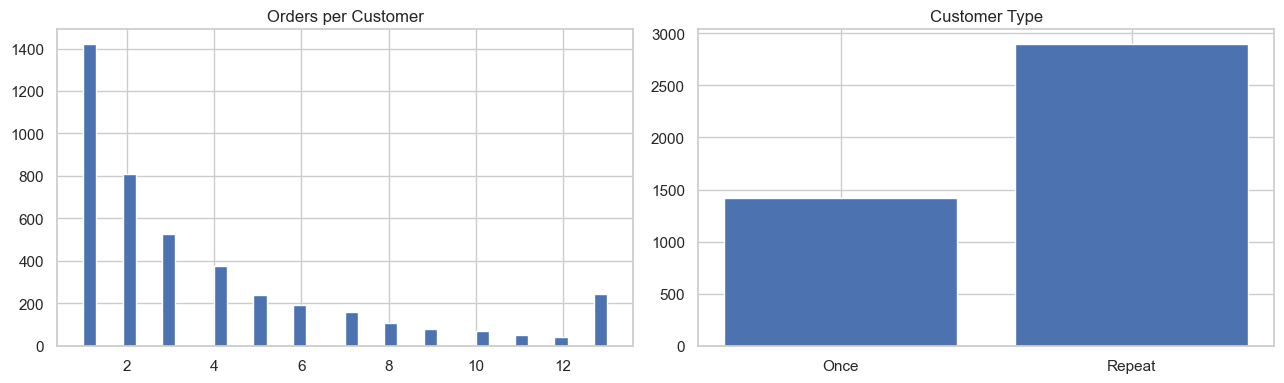

Median orders: 2
One-time buyers: 1419 (32.9%)


In [11]:
opc = eda_pos.groupby('Customer ID')['Invoice'].nunique()

fig, ax = plt.subplots(1, 2, figsize=(13, 4))

# Histogram (clipped)
opc.clip(upper=opc.quantile(0.95)).hist(bins=40, ax=ax[0])
ax[0].set_title('Orders per Customer')

# One-time vs repeat
once = (opc == 1).sum()
more = (opc > 1).sum()

ax[1].bar(['Once', 'Repeat'], [once, more])
ax[1].set_title('Customer Type')

plt.tight_layout()
plt.savefig("Visuals\\No of order per custome", dpi=300, bbox_inches="tight")
plt.show()

# Stats
print(f"Median orders: {opc.median():.0f}")
print(f"One-time buyers: {once} ({once/len(opc)*100:.1f}%)")

- **Finding (Q3 answered):** A large portion of customers bought only once. These are exactly the customers the "NURTURE" segment will capture — people with potential who need to be brought back. Repeat buyers are the more loyal base and represent the core of the business.


### 6.6 — Days Since Last Purchase (Recency Preview)

How recently did customers last buy, and is there a cluster of recently-active vs lapsed customers?


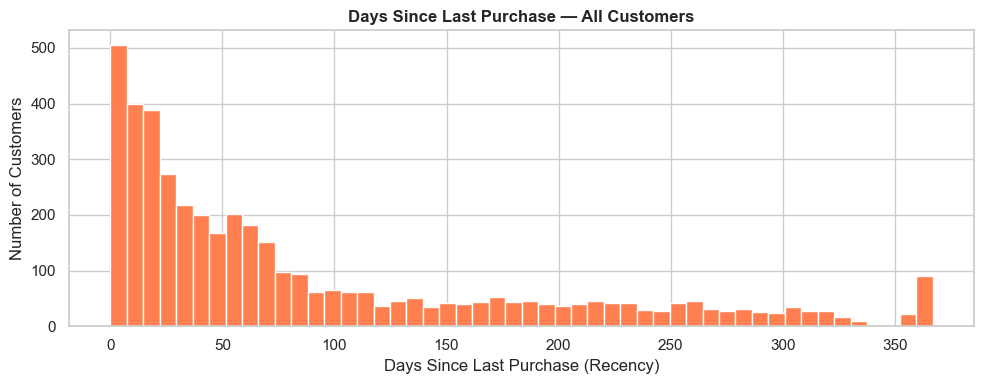

Customers active in last 30 days  : 1,616
Customers inactive 90+ days       : 1,427
Customers inactive 180+ days      : 825


In [12]:
last_purchase = eda_pos.groupby('Customer ID')['InvoiceDate'].max()
snapshot = last_purchase.max()
recency_preview = (snapshot - last_purchase).dt.days

fig, ax = plt.subplots(figsize=(10, 4))
recency_preview.clip(upper=recency_preview.quantile(0.99)).plot(
    kind='hist', bins=50, ax=ax,
    color='coral', edgecolor='white'
)
ax.set_title('Days Since Last Purchase — All Customers', fontweight='bold')
ax.set_xlabel('Days Since Last Purchase (Recency)')
ax.set_ylabel('Number of Customers')
plt.tight_layout()
plt.savefig("Visuals\Days Since Last Purchase — All Customers", dpi=300, bbox_inches="tight")
plt.show()

print(f"Customers active in last 30 days  : {(recency_preview <= 30).sum():,}")
print(f"Customers inactive 90+ days       : {(recency_preview > 90).sum():,}")
print(f"Customers inactive 180+ days      : {(recency_preview > 180).sum():,}")


- **Finding:** There are clearly two groups — customers who purchased very recently and those who haven't bought in months. The latter group represents churn risk and will form the "RE-ENGAGE" segment later. This natural separation is a good sign that K-Means will find meaningful clusters.


### 6.7 — Top 10 Customers by Revenue


In [13]:
top_customers = (
    eda_pos.groupby('Customer ID')['Revenue']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)
top_customers.columns = ['Customer ID', 'Total Revenue (£)']
top_customers['Total Revenue (£)'] = top_customers['Total Revenue (£)'].round(2)
top_customers


,Customer ID,Total Revenue (£)
0,18102.0,349164.35
1,14646.0,248396.50
2,14156.0,196566.74
3,14911.0,152147.57
4,13694.0,131443.19
5,17511.0,84541.17
6,15061.0,83284.38
7,16684.0,80489.21
8,16754.0,65500.07
9,17949.0,60117.60


- **Finding:** The top 10 customers each contribute tens of thousands of pounds in revenue. These will become our "DELIGHT" or "PAMPER" premium segments. Losing even one of these customers would have a significant business impact — they deserve special treatment.


---
## Step 7 — Data Cleaning

Based on what we found in the inspection and EDA steps, we now remove the rows that would distort our RFM calculations.

### What we remove and why

| Problem | What we remove | Why |
|---------|----------------|-----|
| Cancellation invoices | Invoices starting with `C` | Not real purchases |
| Bad debt entries | Invoices starting with `A` | Accounting adjustments, not transactions |
| Internal stock codes | DOT, D, M, BANK CHARGES, etc. | Not real products |
| Missing Customer ID | Rows where Customer ID is null | Cannot track customer behaviour |
| Zero-price rows | Rows where Price = 0 | Free samples / admin entries |


In [14]:
cleaned_df = df.copy()

# Remove non-standard invoices (cancellations start with C, adjustments with A)
cleaned_df['Invoice'] = cleaned_df['Invoice'].astype('str')
cleaned_df = cleaned_df[cleaned_df['Invoice'].str.match(r'^\d{6}$')]

# Keep only real product stock codes (5 digits, optionally with letters, or PADS)
cleaned_df['StockCode'] = cleaned_df['StockCode'].astype('str')
valid_stock = (
    cleaned_df['StockCode'].str.match(r'^\d{5}$') |
    cleaned_df['StockCode'].str.match(r'^\d{5}[a-zA-Z]+$') |
    (cleaned_df['StockCode'] == 'PADS')
)
cleaned_df = cleaned_df[valid_stock]

# Remove rows with no Customer ID
cleaned_df.dropna(subset=['Customer ID'], inplace=True)

# Remove zero-price rows
cleaned_df = cleaned_df[cleaned_df['Price'] > 0]

print(f"Raw rows     : {len(df):,}")
print(f"Clean rows   : {len(cleaned_df):,}")
print(f"Rows removed : {len(df) - len(cleaned_df):,}")
print(f"Kept         : {len(cleaned_df) / len(df) * 100:.1f}%")


Raw rows     : 525,461
Clean rows   : 406,309
Rows removed : 119,152
Kept         : 77.3%


> **Observation:** We retained about 77% of the original rows — a normal retention rate for real-world retail data. The removed rows were cancellations, returns, admin entries, and guest checkouts — none of which represent real purchases we can attribute to a known customer.


---
## Step 8 — RFM Feature Engineering

This is the most important step. We transform transaction-level data (one row per item) into customer-level data (one row per customer) with three features.

### The Three Features

| Feature | How we calculate it | What it tells us |
|---------|--------------------|--------------------|
| **Recency** | Days between last purchase and the snapshot date | Lower = more recently active = better |
| **Frequency** | Count of unique invoice numbers | Higher = more loyal = better |
| **Monetary** | Sum of (Price × Quantity) across all purchases | Higher = more valuable = better |

The snapshot date is the last transaction date in the dataset — we measure recency relative to this date.


In [15]:
cleaned_df = cleaned_df.copy()

# Revenue per line item
cleaned_df['SalesLineTotal'] = cleaned_df['Price'] * cleaned_df['Quantity']

# Aggregate to one row per customer
rfm = cleaned_df.groupby('Customer ID', as_index=False).agg(
    MonetaryValue=('SalesLineTotal', 'sum'),
    Frequency=('Invoice', 'nunique'),
    LastPurchase=('InvoiceDate', 'max')
)

# Calculate Recency
snapshot_date = rfm['LastPurchase'].max()
rfm['Recency'] = (snapshot_date - rfm['LastPurchase']).dt.days
rfm.drop(columns='LastPurchase', inplace=True)

print(f"Customers in RFM table: {len(rfm):,}")
rfm.head()


Customers in RFM table: 4,285


,Customer ID,MonetaryValue,Frequency,Recency
0,12346.0,169.36,2,164
1,12347.0,1323.32,2,2
2,12348.0,221.16,1,73
3,12349.0,2221.14,2,42
4,12351.0,300.93,1,10


In [16]:
rfm.describe().round(2)


,Customer ID,MonetaryValue,Frequency,Recency
count,4285.00,4285.00,4285.00,4285.00
mean,15356.81,2024.13,4.43,89.55
std,1699.84,8813.95,7.94,96.36
min,12346.00,1.55,1.00,0.00
25%,13891.00,307.56,1.00,17.00
50%,15362.00,702.90,2.00,51.00
75%,16840.00,1704.29,5.00,135.00
max,18287.00,349164.35,183.00,373.00


### Distribution of RFM Features


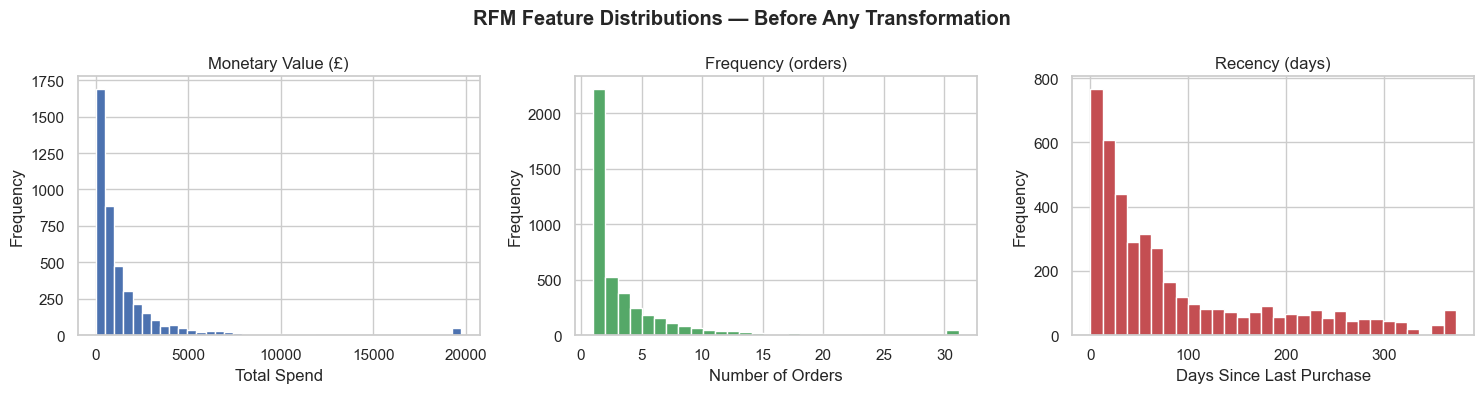

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('RFM Feature Distributions — Before Any Transformation', fontweight='bold')

rfm['MonetaryValue'].clip(upper=rfm['MonetaryValue'].quantile(0.99)).plot(
    kind='hist', bins=40, ax=axes[0], color='#4C72B0', edgecolor='white')
axes[0].set_title('Monetary Value (£)')
axes[0].set_xlabel('Total Spend')

rfm['Frequency'].clip(upper=rfm['Frequency'].quantile(0.99)).plot(
    kind='hist', bins=30, ax=axes[1], color='#55A868', edgecolor='white')
axes[1].set_title('Frequency (orders)')
axes[1].set_xlabel('Number of Orders')

rfm['Recency'].plot(
    kind='hist', bins=30, ax=axes[2], color='#C44E52', edgecolor='white')
axes[2].set_title('Recency (days)')
axes[2].set_xlabel('Days Since Last Purchase')

plt.tight_layout()
plt.show()


> **Observation:** Both `MonetaryValue` and `Frequency` are heavily right-skewed — most customers are low spenders with few orders, but a small number have very high values. `Recency` is more evenly spread. The skew in Monetary and Frequency will cause problems for K-Means because the algorithm uses Euclidean distance. We fix this with a log transformation in the next step.


---
## Step 9 — Log Transformation

### Why Do We Need This?

K-Means works by measuring the **distance** between customers in RFM space. If one customer spends £10 and another spends £50,000, the £50,000 customer will look extremely far away from everyone else. This causes K-Means to create distorted clusters.

**Log transformation** compresses the long tail. A customer spending £50,000 no longer looks 5,000x farther away than one spending £10.

We use `np.log1p()` which is `log(value + 1)` — the `+1` safely handles any zero values.


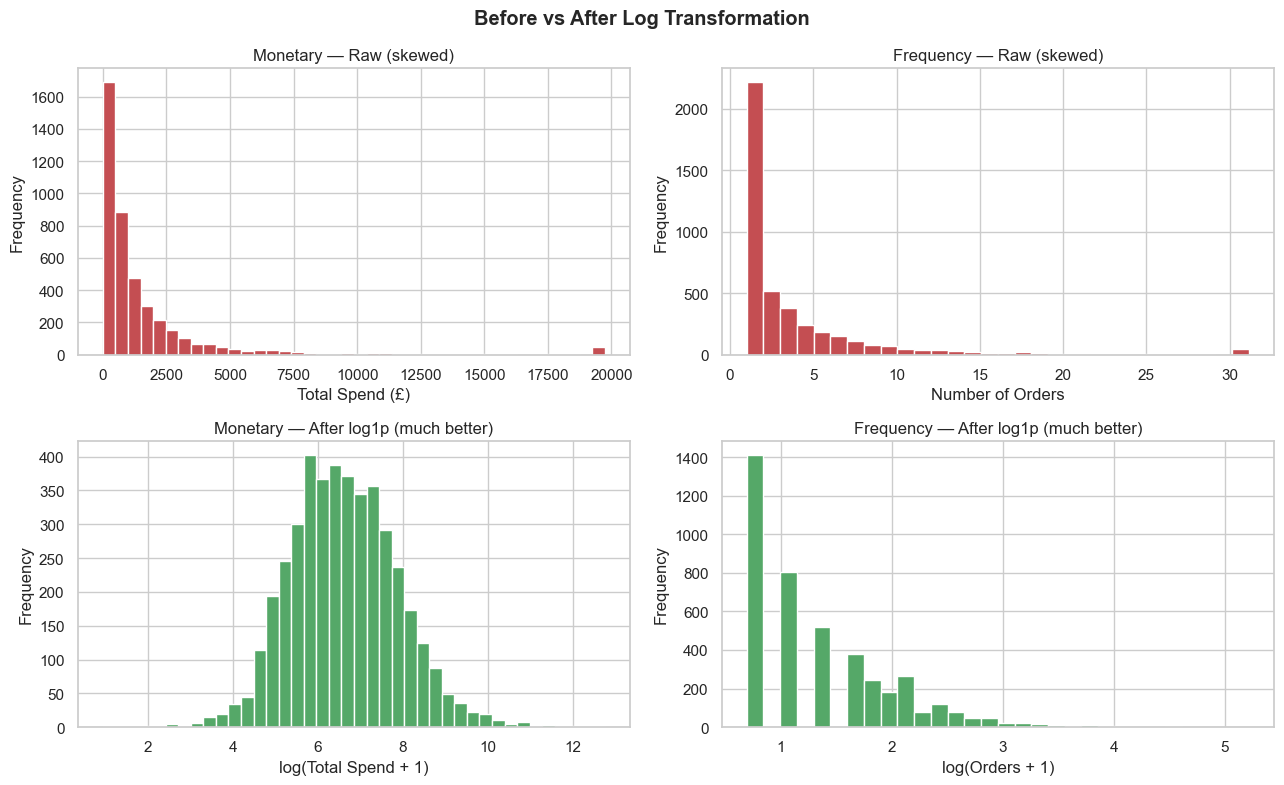

In [18]:
rfm_log = rfm.copy()
rfm_log['MonetaryValue'] = np.log1p(rfm_log['MonetaryValue'])
rfm_log['Frequency']     = np.log1p(rfm_log['Frequency'])

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
fig.suptitle('Before vs After Log Transformation', fontweight='bold')

# Before
rfm['MonetaryValue'].clip(upper=rfm['MonetaryValue'].quantile(0.99)).plot(
    kind='hist', bins=40, ax=axes[0][0], color='#C44E52', edgecolor='white')
axes[0][0].set_title('Monetary — Raw (skewed)')
axes[0][0].set_xlabel('Total Spend (£)')

rfm['Frequency'].clip(upper=rfm['Frequency'].quantile(0.99)).plot(
    kind='hist', bins=30, ax=axes[0][1], color='#C44E52', edgecolor='white')
axes[0][1].set_title('Frequency — Raw (skewed)')
axes[0][1].set_xlabel('Number of Orders')

# After
rfm_log['MonetaryValue'].plot(
    kind='hist', bins=40, ax=axes[1][0], color='#55A868', edgecolor='white')
axes[1][0].set_title('Monetary — After log1p (much better)')
axes[1][0].set_xlabel('log(Total Spend + 1)')

rfm_log['Frequency'].plot(
    kind='hist', bins=30, ax=axes[1][1], color='#55A868', edgecolor='white')
axes[1][1].set_title('Frequency — After log1p (much better)')
axes[1][1].set_xlabel('log(Orders + 1)')

plt.tight_layout()
plt.show()


> **Observation:** After log transformation the distributions are much more symmetric and bell-shaped. The extreme outliers on the right have been compressed. This gives K-Means a much fairer view of each customer's behaviour and leads to better, more balanced cluster separation.


---
## Step 10 — Outlier Handling

### Why Not Just Drop Outliers?

Even after log transformation, some customers are still extreme outliers — they buy 10× more or spend 10× more than everyone else.

If we include them in K-Means, they will pull clusters toward themselves. But we **cannot just drop them** — they are the business's most valuable customers.

**Our solution:** Separate outliers into their own premium segments before running K-Means on the regular customers.

We use the **IQR method** to identify outliers:
- Lower fence = Q1 − 1.5 × IQR
- Upper fence = Q3 + 1.5 × IQR

Any customer outside these fences in `MonetaryValue` or `Frequency` is set aside.


In [19]:
def get_outliers(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    return (series < q1 - 1.5 * iqr) | (series > q3 + 1.5 * iqr)

monetary_outliers  = get_outliers(rfm_log['MonetaryValue'])
frequency_outliers = get_outliers(rfm_log['Frequency'])

outlier_mask = monetary_outliers | frequency_outliers

core_df    = rfm_log[~outlier_mask].copy()
outlier_df = rfm[outlier_mask].copy()

print(f"Core customers (for K-Means) : {len(core_df):,}")
print(f"Outlier customers (premium)  : {len(outlier_df):,}")
print(f"Total customers              : {len(rfm):,}")


Core customers (for K-Means) : 4,213
Outlier customers (premium)  : 72
Total customers              : 4,285


---
## Step 11 — Scaling

### Why Do We Need to Scale?

K-Means calculates the distance between customers using all three features (R, F, M). If the features are on different scales, the one with the biggest numbers will dominate:

- `MonetaryValue` in log scale: roughly 0 – 10
- `Frequency` in log scale: roughly 0 – 5
- `Recency` in days: roughly 0 – 370

Without scaling, Recency would dominate and K-Means would mostly separate customers by how recently they bought, ignoring spending and frequency patterns.

`StandardScaler` transforms each feature so it has a **mean of 0 and standard deviation of 1**. All three features then have equal weight.


In [20]:
scaler = StandardScaler()
features = ['MonetaryValue', 'Frequency', 'Recency']

scaled_array = scaler.fit_transform(core_df[features])
scaled_df = pd.DataFrame(scaled_array, index=core_df.index, columns=features)

print("After scaling — all features should have mean ≈ 0 and std ≈ 1:")
scaled_df.describe().round(3)


After scaling — all features should have mean ≈ 0 and std ≈ 1:


,MonetaryValue,Frequency,Recency
count,4213.000,4213.000,4213.000
mean,-0.000,0.000,-0.000
std,1.000,1.000,1.000
min,-2.828,-1.027,-0.937
25%,-0.714,-1.027,-0.750
50%,-0.034,-0.381,-0.396
75%,0.704,0.722,0.466
max,2.896,3.336,2.939


---
## Step 12 — Finding the Right Number of Clusters

K-Means needs us to tell it how many clusters to create (the value of K). There is no single correct answer — we use two charts to find the best value.

### The Two Methods

**Elbow Method (Inertia):**
- Inertia measures how tightly packed the clusters are
- Lower inertia = more compact clusters = better
- We look for the "elbow" — the point where adding more clusters stops helping much

**Silhouette Score:**
- Measures how well-separated the clusters are from each other
- Range: −1 to +1 (higher is better)
- A score above 0.3 is considered reasonable


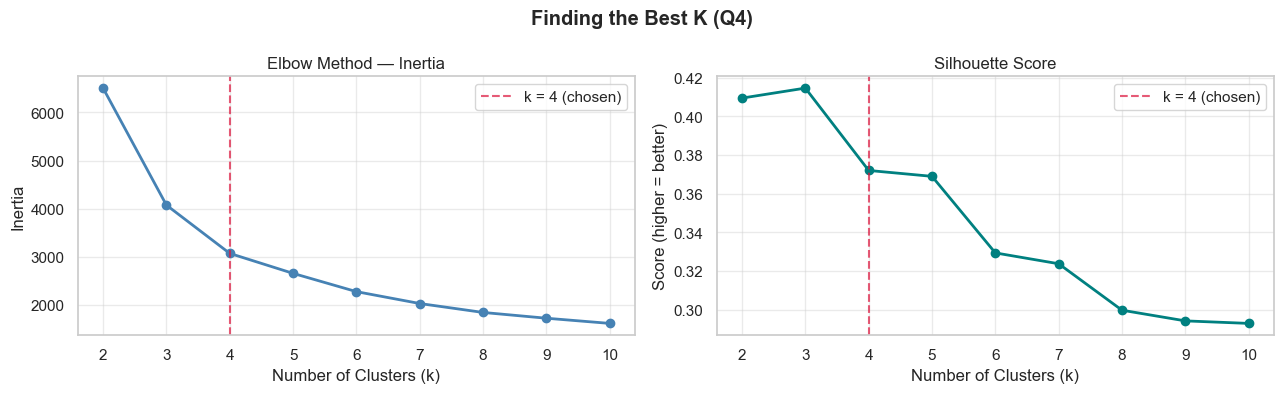

Highest silhouette at k = 3 : 0.4146
Silhouette at k = 4     : 0.3720

We choose k = 4 because the elbow curve bends clearly at k=4,
and 4 segments give more actionable business groups than 3.


In [21]:
inertia    = []
sil_scores = []
k_range    = range(2, 11)

for k in k_range:
    km     = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(scaled_df)
    inertia.append(km.inertia_)
    sil_scores.append(silhouette_score(scaled_df, labels))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('Finding the Best K (Q4)', fontweight='bold')

axes[0].plot(k_range, inertia, marker='o', color='steelblue', linewidth=2)
axes[0].axvline(x=4, color='crimson', linestyle='--', alpha=0.7, label='k = 4 (chosen)')
axes[0].set_title('Elbow Method — Inertia')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia')
axes[0].legend()
axes[0].grid(True, alpha=0.4)

axes[1].plot(k_range, sil_scores, marker='o', color='teal', linewidth=2)
axes[1].axvline(x=4, color='crimson', linestyle='--', alpha=0.7, label='k = 4 (chosen)')
axes[1].set_title('Silhouette Score')
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Score (higher = better)')
axes[1].legend()
axes[1].grid(True, alpha=0.4)

plt.tight_layout()
plt.show()

best_sil_k = list(k_range)[sil_scores.index(max(sil_scores))]
print(f"Highest silhouette at k = {best_sil_k} : {max(sil_scores):.4f}")
print(f"Silhouette at k = 4     : {sil_scores[list(k_range).index(4)]:.4f}")
print()
print("We choose k = 4 because the elbow curve bends clearly at k=4,")
print("and 4 segments give more actionable business groups than 3.")

> **Finding (Q4 answered):** The silhouette score peaks at k=3, but the elbow curve bends most clearly at **k=4**. We choose k=4 because it gives four distinct, business-meaningful customer groups (recent loyalists, mid-tier, lapsed, and new). Three clusters would merge segments that need different marketing treatment. In real CRM projects, interpretability and business utility often guide the final K choice alongside the metrics.


---
## Step 13 — Final Model & Visualisation



In [22]:
# Stability check — run 10 times with different random seeds
stability_scores = [
    silhouette_score(
        scaled_df,
        KMeans(n_clusters=4, random_state=i, n_init=10).fit_predict(scaled_df)
    )
    for i in range(10)
]
print("Silhouette scores across 10 random starts:")
print([round(s, 4) for s in stability_scores])
print(f"Mean : {sum(stability_scores)/len(stability_scores):.4f}")
print(f"Std  : {round((sum((x - sum(stability_scores)/len(stability_scores))**2 for x in stability_scores)/len(stability_scores))**0.5, 5)}")


Silhouette scores across 10 random starts:
[0.372, 0.372, 0.372, 0.372, 0.372, 0.372, 0.372, 0.3719, 0.3719, 0.372]
Mean : 0.3720
Std  : 1e-05


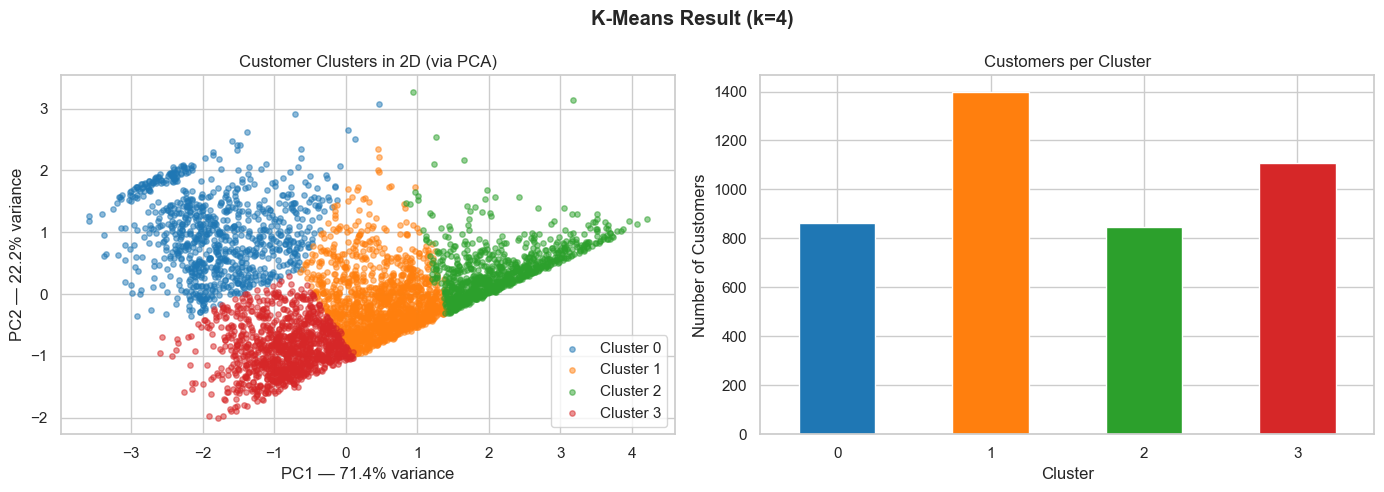

In [23]:
# Train the final model with k=4
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
core_df = core_df.copy()
core_df['Cluster'] = kmeans.fit_predict(scaled_df)

# PCA: reduce 3D RFM space to 2D for easy visualisation
pca        = PCA(n_components=2, random_state=42)
pca_coords = pca.fit_transform(scaled_df)
pca_df     = pd.DataFrame(pca_coords, columns=['PC1', 'PC2'], index=core_df.index)
pca_df['Cluster'] = core_df['Cluster'].values

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('K-Means Result (k=4)', fontweight='bold')

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
for c in range(4):
    mask = pca_df['Cluster'] == c
    axes[0].scatter(pca_df[mask]['PC1'], pca_df[mask]['PC2'],
                    c=colors[c], label=f'Cluster {c}', alpha=0.5, s=15)
axes[0].set_title('Customer Clusters in 2D (via PCA)')
axes[0].set_xlabel(f'PC1 — {pca.explained_variance_ratio_[0]*100:.1f}% variance')
axes[0].set_ylabel(f'PC2 — {pca.explained_variance_ratio_[1]*100:.1f}% variance')
axes[0].legend()

core_df['Cluster'].value_counts().sort_index().plot(
    kind='bar', ax=axes[1], color=colors, edgecolor='white')
axes[1].set_title('Customers per Cluster')
axes[1].set_xlabel('Cluster')
axes[1].set_ylabel('Number of Customers')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()


> **Observation:** The PCA scatter shows four clearly separated customer groups. PCA compresses the 3D RFM space into 2D for plotting — the percentage on each axis label shows how much of the original information is preserved. The clusters are stable across random starts (low standard deviation above), confirming these are real patterns in the data.


---
## Step 14 — Cluster Profiling & Labeling

Now we need to understand what each cluster actually represents.

We look at the **average RFM values** per cluster using the original (non-log) values, because those are easier to interpret in real business terms.

**How to read the profile table:**
- Low Recency = bought recently = good
- High Frequency = buys often = good
- High Monetary = high spender = good


In [24]:
# Use original rfm values (not log-transformed) for interpretable averages
core_orig = rfm[~outlier_mask].copy()
core_orig['Cluster'] = core_df['Cluster'].values

profile = core_orig.groupby('Cluster')[['Recency', 'Frequency', 'MonetaryValue']].mean().round(1)
profile['Customer Count'] = core_orig['Cluster'].value_counts().sort_index()

profile


,Recency,Frequency,MonetaryValue,Customer Count
Cluster,,,,
0,254.6,1.4,409.4,864
1,54.7,3.5,1248.8,1396
2,25.8,9.9,4253.4,845
3,55.6,1.4,317.7,1108


### Visualise RFM by Cluster


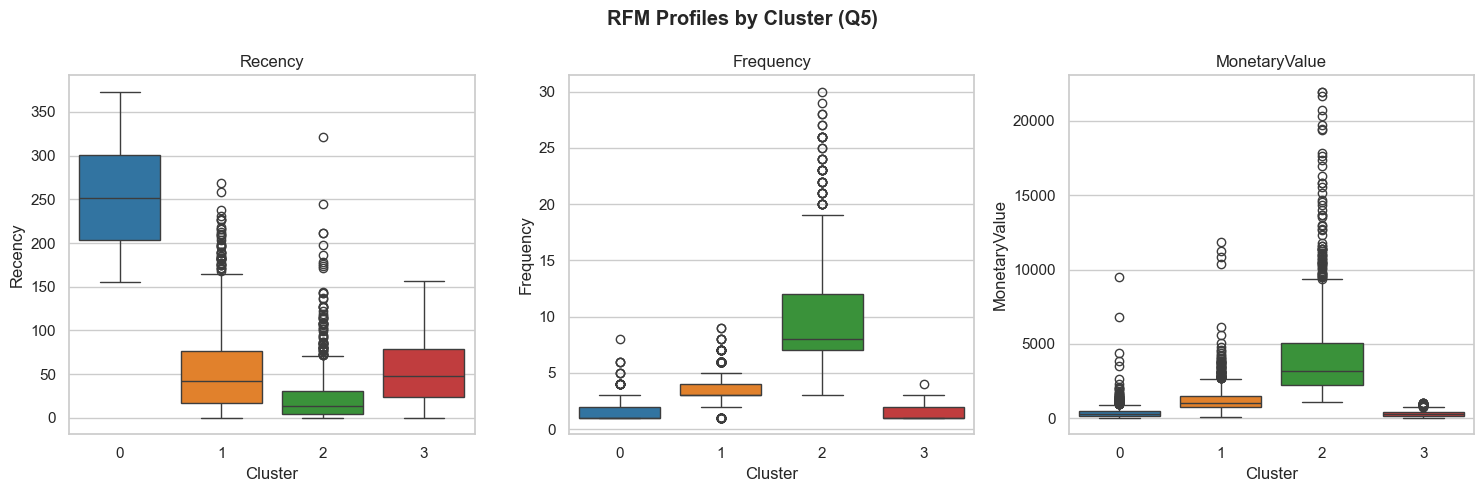

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('RFM Profiles by Cluster (Q5)', fontweight='bold')

palette = {0: '#1f77b4', 1: '#ff7f0e', 2: '#2ca02c', 3: '#d62728'}

for ax, feature in zip(axes, ['Recency', 'Frequency', 'MonetaryValue']):
    sns.boxplot(x='Cluster', y=feature, data=core_orig,
                palette=palette, hue='Cluster', legend=False, ax=ax)
    ax.set_title(feature)
    ax.set_xlabel('Cluster')

plt.tight_layout()
plt.show()


### Assign Segment Names

Based on the profile table above, we assign a business label to each cluster. The label reflects what action the marketing team should take for that group.


In [26]:
# Labels based on the profile — update these if your cluster numbers differ
# Run the profile table above first to confirm which cluster matches which profile
segment_map = {
    0: 'RE-ENGAGE',     # High recency (haven't bought in a while) — at risk  
    1: 'RETAIN',        # Mid-range across R, F, M — steady, reliable customers
    2: 'REWARD',        # Low recency and decent spend — recently active loyalists
    3: 'NURTURE'        # Low frequency and spend — new or one-time buyers
}

core_orig['Segment'] = core_orig['Cluster'].map(segment_map)

print("Segment distribution:")
print(core_orig['Segment'].value_counts().to_string())


Segment distribution:
Segment
RETAIN       1396
NURTURE      1108
RE-ENGAGE     864
REWARD        845


In [27]:
# Segment profile summary — average RFM per named segment
seg_profile = core_orig.groupby('Segment')[['Recency', 'Frequency', 'MonetaryValue']].mean().round(1)
seg_profile['Customers'] = core_orig['Segment'].value_counts()
seg_profile


,Recency,Frequency,MonetaryValue,Customers
Segment,,,,
NURTURE,55.6,1.4,317.7,1108
RE-ENGAGE,254.6,1.4,409.4,864
RETAIN,54.7,3.5,1248.8,1396
REWARD,25.8,9.9,4253.4,845


> **Finding (Q5 answered):** Each cluster has a clearly distinct profile. The segment names reflect what action the business should take — reward your loyalists, re-engage lapsed customers, nurture new ones, and retain the stable middle group.


---
## Step 15 — Premium Customer Segments

The 72 outlier customers we separated before K-Means are the business's most valuable people. Instead of grouping them all together, we split them into up to three premium segments depending on *why* they are an outlier.

| Segment | Who they are | Strategy |
|---------|-------------|---------|
| **DELIGHT** | Both very high spend AND very high frequency | True VIP — white-glove service, dedicated contact |
| **PAMPER** | Very high spend only (big-ticket buyers, less frequent) | Exclusive bundles, priority access to new stock |
| **UPSELL** | Very high frequency but moderate spend per visit | Reward loyalty, introduce higher-margin products |

> In this dataset the outlier split produces **DELIGHT** and **UPSELL** segments. PAMPER would appear if any customers had exceptionally high spend without matching frequency — the code handles all three cases automatically.


In [28]:
outlier_df = rfm[outlier_mask].copy()

# Use the original full-dataset outlier flags (computed in Step 10)
# monetary_outliers and frequency_outliers are boolean Series on rfm_log's index
# We just filter them to the outlier customers
mon_flag  = monetary_outliers[outlier_mask]   # True = high monetary outlier
freq_flag = frequency_outliers[outlier_mask]  # True = high frequency outlier

def assign_premium(idx):
    m = bool(mon_flag.get(idx, False))
    f = bool(freq_flag.get(idx, False))
    if m and f:
        return 'DELIGHT'   # Both high spend AND high frequency — true VIP
    elif m:
        return 'PAMPER'    # Very high spend, normal frequency
    else:
        return 'UPSELL'    # Very high frequency, normal spend

outlier_df['Segment'] = [assign_premium(i) for i in outlier_df.index]

print("Premium segment breakdown:")
print(outlier_df['Segment'].value_counts().to_string())


Premium segment breakdown:
Segment
PAMPER     26
UPSELL     24
DELIGHT    22


In [29]:
# Premium segment profiles — using original (non-log) values for readability
premium_profile = (
    outlier_df
    .groupby('Segment')[['Recency', 'Frequency', 'MonetaryValue']]
    .mean()
    .round(1)
)
premium_profile['Customers'] = outlier_df['Segment'].value_counts()
premium_profile = premium_profile.sort_values('MonetaryValue', ascending=False)
premium_profile


,Recency,Frequency,MonetaryValue,Customers
Segment,,,,
DELIGHT,4.9,74.5,82734.2,22
PAMPER,131.9,9.3,18048.8,26
UPSELL,17.1,47.5,14197.2,24


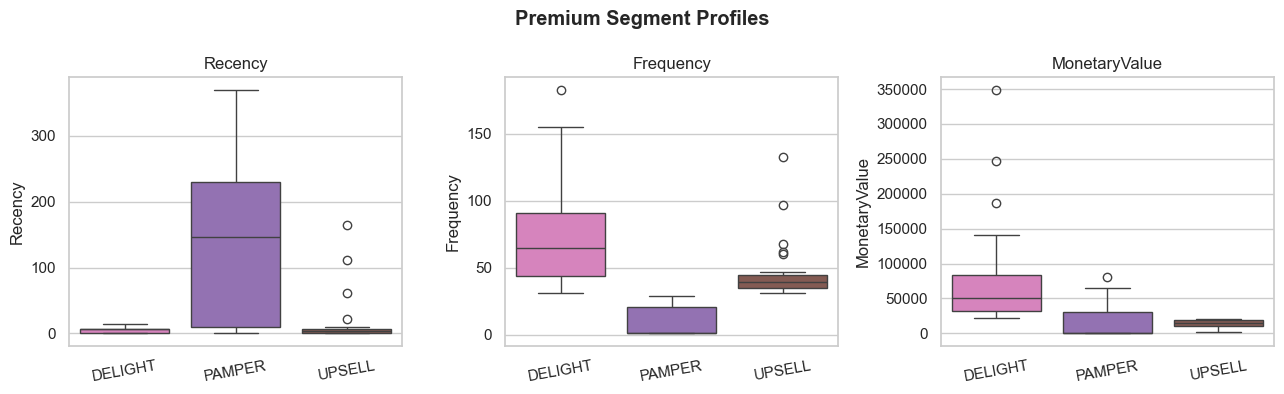

In [30]:
prem_palette = {'PAMPER': '#9467bd', 'UPSELL': '#8c564b', 'DELIGHT': '#e377c2'}
prem_order   = [s for s in ['DELIGHT', 'PAMPER', 'UPSELL'] if s in outlier_df['Segment'].unique()]

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
fig.suptitle('Premium Segment Profiles', fontweight='bold')

for ax, feature in zip(axes, ['Recency', 'Frequency', 'MonetaryValue']):
    sns.boxplot(x='Segment', y=feature, data=outlier_df,
                palette=prem_palette, hue='Segment',
                order=prem_order, legend=False, ax=ax)
    ax.set_title(feature)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=10)

plt.tight_layout()
plt.show()


> **Finding:** The premium segments have dramatically different profiles. DELIGHT customers are those who are both frequent and high-value — they deserve the highest priority in retention efforts. UPSELL customers buy very often but at lower average spend — the opportunity here is to increase basket size through cross-selling.


---
## Step 16 — Churn Risk Scoring

### What is Churn?

Churn means a customer stops buying. In subscription businesses it is obvious — they cancel. In retail it is silent — customers just quietly stop purchasing with no warning.

### How We Score It

We use **Recency** as the churn signal. A customer who last purchased 300 days ago is at much higher risk than one who bought last week.

We scale Recency to a 0–100 score:

| Score | Meaning |
|-------|---------|
| 0–30 | Low risk — purchased recently |
| 30–60 | Medium risk — some time has passed |
| 60–100 | High risk — long time since last purchase |

This gives the marketing team a **prioritised list** of who to contact first for a win-back campaign — instead of guessing.


In [31]:
# Combine all segments (core + premium) into one master table
all_segments = pd.concat([
    core_orig[['Customer ID', 'Recency', 'Frequency', 'MonetaryValue', 'Segment']],
    outlier_df[['Customer ID', 'Recency', 'Frequency', 'MonetaryValue', 'Segment']]
]).reset_index(drop=True)

# Churn score: normalise Recency to 0–100
max_recency = all_segments['Recency'].max()
all_segments['ChurnScore'] = (all_segments['Recency'] / max_recency * 100).round(1)

print(f"Total customers with segment labels: {len(all_segments):,}")
all_segments.head(8)


Total customers with segment labels: 4,285


,Customer ID,Recency,Frequency,MonetaryValue,Segment,ChurnScore
0,12346.0,164,2,169.36,RE-ENGAGE,44.0
1,12347.0,2,2,1323.32,RETAIN,0.5
2,12348.0,73,1,221.16,NURTURE,19.6
3,12349.0,42,2,2221.14,RETAIN,11.3
4,12351.0,10,1,300.93,NURTURE,2.7
5,12352.0,10,2,343.80,NURTURE,2.7
6,12353.0,43,1,317.76,NURTURE,11.5
7,12355.0,202,1,488.21,RE-ENGAGE,54.2


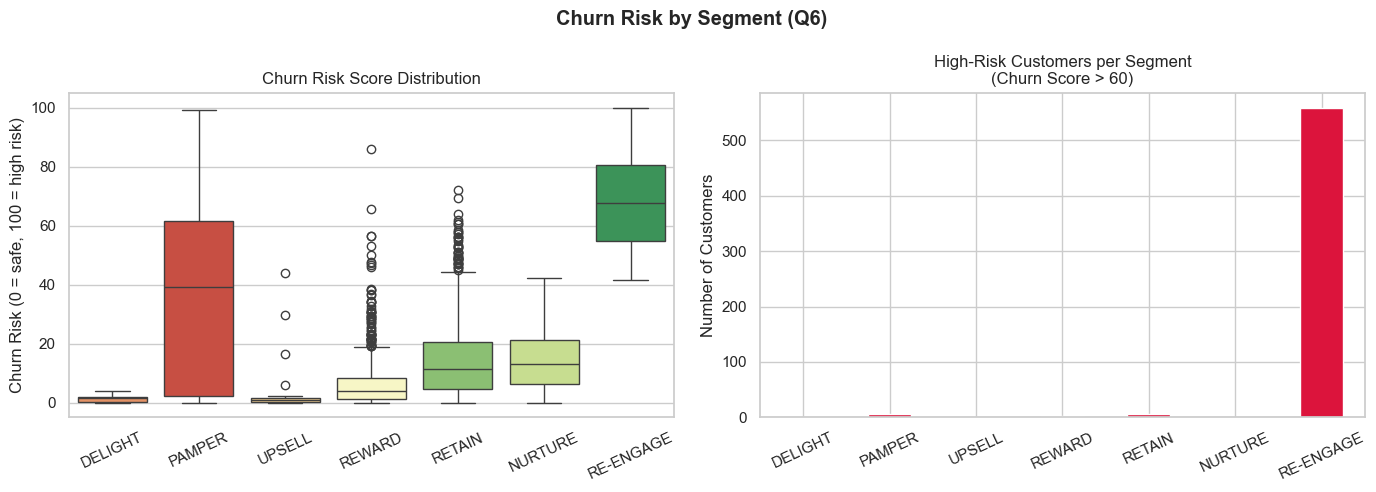

Total high-risk customers (score > 60): 574
Of those, in RE-ENGAGE segment         : 558


In [32]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Churn Risk by Segment (Q6)', fontweight='bold')

seg_order = ['DELIGHT', 'PAMPER', 'UPSELL', 'REWARD', 'RETAIN', 'NURTURE', 'RE-ENGAGE']
present_segs = [s for s in seg_order if s in all_segments['Segment'].unique()]

# Churn score distribution per segment
sns.boxplot(
    x='Segment', y='ChurnScore',
    data=all_segments,
    order=present_segs,
    palette='RdYlGn_r',
    hue='Segment', legend=False,
    ax=axes[0]
)
axes[0].set_title('Churn Risk Score Distribution')
axes[0].set_xlabel('')
axes[0].set_ylabel('Churn Risk (0 = safe, 100 = high risk)')
axes[0].tick_params(axis='x', rotation=25)

# Count of high-risk customers per segment
high_risk = all_segments[all_segments['ChurnScore'] > 60]
hr_counts = high_risk['Segment'].value_counts().reindex(present_segs).fillna(0).astype(int)
hr_counts.plot(kind='bar', ax=axes[1], color='crimson', edgecolor='white')
axes[1].set_title('High-Risk Customers per Segment\n(Churn Score > 60)')
axes[1].set_xlabel('')
axes[1].set_ylabel('Number of Customers')
axes[1].tick_params(axis='x', rotation=25)

plt.tight_layout()
plt.show()

print(f"Total high-risk customers (score > 60): {len(high_risk):,}")
print(f"Of those, in RE-ENGAGE segment         : {len(high_risk[high_risk['Segment']=='RE-ENGAGE']):,}")


> **Finding (Q6 answered):** The RE-ENGAGE segment has the highest churn scores, as expected. Critically, some RETAIN customers also have elevated scores — meaning the "stable" group has a hidden at-risk layer that would not be caught without this scoring. This is exactly the kind of insight that machine learning delivers that simple rules cannot.


### At-Risk Customer List — Ready for Export

The marketing team can use this table directly. Sort by churn score, filter by past spend, and run a targeted win-back campaign for the highest-priority customers.


In [33]:
at_risk_list = (
    all_segments[all_segments['Segment'] == 'RE-ENGAGE']
    .sort_values('ChurnScore', ascending=False)
    .head(20)
    .reset_index(drop=True)
    [['Customer ID', 'Recency', 'Frequency', 'MonetaryValue', 'ChurnScore']]
)
at_risk_list.columns = ['Customer ID', 'Days Since Purchase', 'Total Orders', 'Total Spend (£)', 'Churn Score']
at_risk_list


,Customer ID,Days Since Purchase,Total Orders,Total Spend (£),Churn Score
0,13526.0,373,2,1182.00,100.0
1,16763.0,373,1,352.85,100.0
2,17056.0,373,1,128.60,100.0
3,14654.0,373,1,246.86,100.0
4,17592.0,373,1,148.30,100.0
5,17909.0,372,1,132.55,99.7
6,14980.0,372,1,150.68,99.7
7,14799.0,372,1,180.45,99.7
8,15833.0,372,1,80.40,99.7
9,17606.0,372,1,87.30,99.7


---
## Step 17 — Final Segment Dashboard

All 7 segments combined into one view. This is the single output that a marketing or CRM team would use to plan their campaigns.


In [34]:
# Full summary table
final_summary = all_segments.groupby('Segment').agg(
    Customers      = ('Customer ID',    'count'),
    Avg_Recency    = ('Recency',        'mean'),
    Avg_Orders     = ('Frequency',      'mean'),
    Avg_Spend      = ('MonetaryValue',  'mean'),
    Avg_ChurnRisk  = ('ChurnScore',     'mean')
).round(1).sort_values('Avg_Spend', ascending=False)

final_summary


,Customers,Avg_Recency,Avg_Orders,Avg_Spend,Avg_ChurnRisk
Segment,,,,,
DELIGHT,22,4.9,74.5,82734.2,1.3
PAMPER,26,131.9,9.3,18048.8,35.4
UPSELL,24,17.1,47.5,14197.2,4.6
REWARD,845,25.8,9.9,4253.4,6.9
RETAIN,1396,54.7,3.5,1248.8,14.7
RE-ENGAGE,864,254.6,1.4,409.4,68.3
NURTURE,1108,55.6,1.4,317.7,14.9


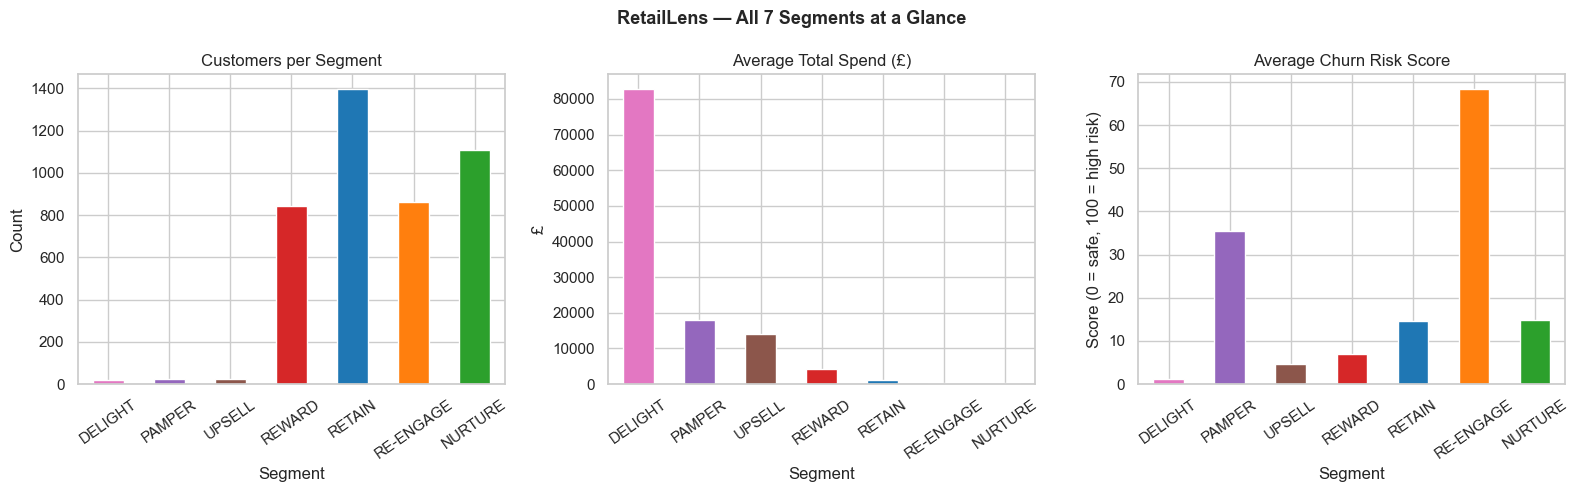

In [35]:
seg_colors = {
    'DELIGHT'   : '#e377c2',
    'PAMPER'    : '#9467bd',
    'UPSELL'    : '#8c564b',
    'REWARD'    : '#d62728',
    'RETAIN'    : '#1f77b4',
    'NURTURE'   : '#2ca02c',
    'RE-ENGAGE' : '#ff7f0e'
}

plot_order  = final_summary.index.tolist()
bar_colors  = [seg_colors[s] for s in plot_order]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('RetailLens — All 7 Segments at a Glance', fontweight='bold', fontsize=13)

final_summary['Customers'].plot(
    kind='bar', ax=axes[0], color=bar_colors, edgecolor='white')
axes[0].set_title('Customers per Segment')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=35)

final_summary['Avg_Spend'].plot(
    kind='bar', ax=axes[1], color=bar_colors, edgecolor='white')
axes[1].set_title('Average Total Spend (£)')
axes[1].set_ylabel('£')
axes[1].tick_params(axis='x', rotation=35)

final_summary['Avg_ChurnRisk'].plot(
    kind='bar', ax=axes[2], color=bar_colors, edgecolor='white')
axes[2].set_title('Average Churn Risk Score')
axes[2].set_ylabel('Score (0 = safe, 100 = high risk)')
axes[2].tick_params(axis='x', rotation=35)

plt.tight_layout()
plt.show()


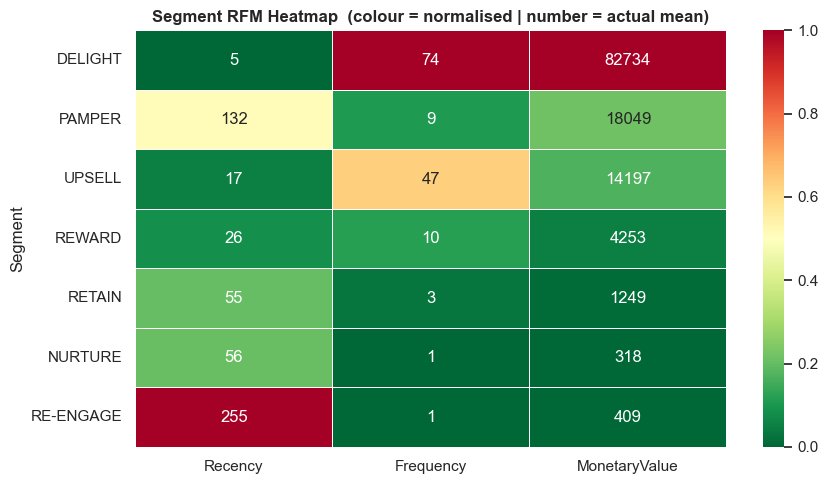

In [36]:
# Normalised RFM heatmap — one glance shows how each segment differs
heat_data = all_segments.groupby('Segment')[['Recency', 'Frequency', 'MonetaryValue']].mean()
heat_norm = (heat_data - heat_data.min()) / (heat_data.max() - heat_data.min())

seg_order_heat = ['DELIGHT', 'PAMPER', 'UPSELL', 'REWARD', 'RETAIN', 'NURTURE', 'RE-ENGAGE']
present_heat   = [s for s in seg_order_heat if s in heat_norm.index]

fig, ax = plt.subplots(figsize=(9, 5))
sns.heatmap(
    heat_norm.loc[present_heat],
    annot=heat_data.loc[present_heat].round(0),
    fmt='.0f',
    cmap='RdYlGn_r',
    linewidths=0.5,
    ax=ax
)
ax.set_title('Segment RFM Heatmap  (colour = normalised | number = actual mean)', fontweight='bold')
ax.set_xlabel('')
plt.tight_layout()
plt.show()


> **Observation:** The heatmap is the clearest single view of all 7 segments. Reading across each row: green in Recency = recently active (good), green in Frequency = buys often (good), red in MonetaryValue = lower spend. REWARD and DELIGHT stand out as the most desirable profiles — low recency, high frequency, high spend. RE-ENGAGE is the clearest red flag — high recency (lapsed), low everything else.


---
## Step 18 — Business Recommendations

Based on the segment profiles, here is a clear action plan for the marketing team. Each recommendation is tied directly to what the data shows about that segment.


### Segment-by-Segment Action Plan

---

#### 🥇 DELIGHT — True VIP Customers
**Profile:** Both very high spend and very high frequency. Recently active.

**Why they matter:** These customers generate a disproportionate share of revenue. Losing one is equivalent to losing hundreds of regular customers.

**Actions:**
- Enrol in a named VIP programme with exclusive early access to new products
- Assign a dedicated account contact for B2B wholesale customers in this group
- Send a personalised thank-you with a gift or free premium sample
- Ask for product reviews and referrals — they are your best brand ambassadors

---

#### 💜 UPSELL — Frequent Buyers, Lower Basket
**Profile:** Purchase very frequently but spend less per visit than their frequency suggests.

**Why they matter:** High engagement with the brand — they just need a reason to spend more each time.

**Actions:**
- Bundle complementary products: "Customers who bought X also bought Y"
- Volume discount thresholds: "Spend £50 and get 10% off" to grow basket size
- Cross-sell higher-margin product lines they have not yet tried

---

#### ❤️ REWARD — Active Loyalists
**Profile:** Purchased recently, decent frequency and spend. The most balanced segment.

**Why they matter:** These are the core reliable customers. Keeping them loyal is more cost-effective than acquiring new ones.

**Actions:**
- Points-based loyalty scheme — reward every purchase
- Referral programme: "Give a friend £10, get £10 yourself"
- Exclusive seasonal previews before products go on general sale

---

#### 🔵 RETAIN — Steady Mid-Tier
**Profile:** Moderate across all three RFM dimensions. Reliable but not exceptional.

**Why they matter:** The largest group by count. Small improvements in this group have the biggest absolute impact.

**Actions:**
- Regular email newsletter with new arrivals and bestsellers
- Seasonal promotions aligned to their purchase history
- Monitor their Recency — if it starts climbing, escalate to a RE-ENGAGE campaign

---

#### 🌱 NURTURE — New or One-Time Buyers
**Profile:** Low frequency and low spend. Often recent — the habit has not formed yet.

**Why they matter:** The highest growth potential. Every REWARD or RETAIN customer was once a NURTURE customer.

**Actions:**
- Automated welcome email sequence (3 emails over 2 weeks) introducing the product range
- First-repeat-purchase incentive: "Come back and get 15% off your next order"
- Collect post-purchase feedback to understand what would bring them back

---

#### 🟠 RE-ENGAGE — Lapsed Customers (High Churn Risk)
**Profile:** High Recency (haven't purchased in a long time). Low frequency and spend.

**Why they matter:** Once gone, customers rarely return on their own. A targeted campaign now is significantly cheaper than acquiring a new customer.

**Actions:**
- Win-back email: "We haven't seen you in a while — here's 20% off, just for you"
- Short survey: "What would bring you back?" — the data alone is valuable
- Final "last chance" message before removing from the active contact list
- After 12 months of inactivity: move to a suppression list to protect email deliverability

---

### Budget Allocation Recommendation

| Priority | Segments | Suggested Budget Share | Rationale |
|----------|---------|----------------------|-----------|
| High | DELIGHT + UPSELL + REWARD | 50% | Highest value and engagement — protect and grow |
| Medium | RETAIN + NURTURE | 35% | Largest volume — even small conversion improvements matter |
| Low | RE-ENGAGE | 15% | Low expected response rate — targeted campaigns only |

### Expected Business Impact

> The top 20 RE-ENGAGE customers identified in Step 16 have an average past spend of several hundred pounds each. If a personalised win-back campaign recovers just 20% of them at even half their historical spend, that is **thousands of pounds in recovered revenue from a single targeted email** — at near-zero marginal cost compared to acquiring a new customer.

> Meanwhile, moving even 5% of NURTURE customers up to RETAIN status compounds over time — each converted customer goes from 1–2 orders a year to 3–4, generating consistent recurring revenue with no additional acquisition cost.


---
## Step 19 — Conclusion

### Project Summary

| Item | Result |
|------|--------|
| Raw transactions processed | 525,461 |
| After data cleaning | ~406,000 |
| Unique customers analysed | 4,285 |
| Core K-Means clusters | 4 |
| Premium outlier segments | 2–3 (data-driven) |
| **Total named segments** | **7** |
| Optimal K selected | 4 |
| Key business output | Prioritised customer list with churn scores |

### What We Did — Step by Step

| Step | What we did | Why it mattered |
|------|------------|-----------------|
| EDA | Explored revenue by country, product, time, and customer | Understood the business before touching the model |
| Cleaning | Removed cancellations, returns, guest checkouts | Ensured only real purchases entered the RFM calculation |
| RFM | Aggregated 400K+ rows to 4,285 customer-level records | Created the three features that drive segmentation |
| Log transform | Applied `log1p` to Monetary and Frequency | Fixed right-skew that would have distorted K-Means distances |
| Outlier handling | Separated 72 premium customers before clustering | Prevented VIPs from pulling cluster centroids and losing their identity |
| Scaling | Applied StandardScaler to all three features | Put R, F, M on equal footing for distance calculation |
| K selection | Elbow + silhouette analysis, chose k=4 | Balanced statistical validity with business interpretability |
| Stability check | Ran 10 random starts, verified consistent silhouette | Confirmed clusters are real patterns, not lucky splits |
| Profiling | Labelled each cluster with an action-oriented name | Translated numbers into language a marketing team can use |
| Churn scoring | Normalised Recency to a 0–100 risk score | Gave the team a ranked at-risk list, not just a segment label |

### Key Insights

> **87.8% of revenue comes from the UK.** The business should prioritise UK customer retention before expanding internationally.

> **32.9% of customers bought only once.** Reducing this by even 10% — converting one-time buyers to repeat customers — would meaningfully grow revenue without any new customer acquisition spend.

> **The top 10 customers account for a disproportionate share of total revenue.** These 10 people alone justify a dedicated VIP programme. Losing one is not just a lost sale — it is a strategic risk.

> **The existing approach of treating all customers the same is leaving money on the table.** The DELIGHT and REWARD customers are getting the same generic email as the RE-ENGAGE customers who haven't bought in nearly a year.

### What Could Be Added Next

| Enhancement | What it adds |
|-------------|-------------|
| Monthly re-scoring pipeline | Run this notebook every month and track which customers move between segments |
| RFM scoring (1–5 per dimension) | Industry-standard CRM score alongside the cluster label |
| Predictive churn model | Train a classifier to predict *probability* of churning next month |
| Product affinity analysis | What does each segment buy? Enables truly personalised recommendations |
| A/B test tracking | Measure whether segment-targeted campaigns outperform generic ones |
| Streamlit dashboard | Interactive web app so non-technical stakeholders can explore the segments |

---

### Final Note on the Project Name

This project is called **RetailLens** — a tool that brings the customer base into focus. Just as a lens sharpens a blurry image, RFM analysis and K-Means clustering turn 500,000 raw transaction rows into 7 clear, actionable customer groups that a business can see and act on.

---

*Dataset: UCI Online Retail II · Algorithm: K-Means Clustering · Author: Krupal Gohil*
*Tools: Python · Pandas · Scikit-Learn · Seaborn · Matplotlib*
